# Pose Scoring Model Training

In [16]:
import numpy as np
import re
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import pickle
import os
import seaborn as sns
from pprint import pprint
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from services.ClassifyingService import ClassifyingService
from services.VisualisationService import save_visualized_video
from repositories.MediapipeSegmentationRepository import MediapipeSegmentationRepository

### Configuration
This block defines constants for file paths, number of segments, and pose labels.

In [17]:
pose_names = ("runup", "takeoff", "flight1_handplacement", "flight2", "landing")
pose_labels = {i: [name] for i, name in enumerate(pose_names)}

video_folder = "./dataset/leap/videos/spreidsprong"
pose_labels_csv = "./dataset/leap/features/vault_labels.csv"

video_names = os.listdir(video_folder)
collect_features = False

### Skeleton Feature Extraction
This block processes all videos in the `video_folder` to extract skeleton features using the `MediapipeSegmentationRepository`. The extracted features are saved to a JSON file. If the JSON file already exists, this step is skipped.

In [18]:

if collect_features:
    segmentation_repository = MediapipeSegmentationRepository()
    features = []
    masks = []
    for video_name in tqdm(video_names):
        full_video_path = os.path.join(video_folder, video_name)
        frames, feature_tensor, mask = segmentation_repository.process_video_stgcn(full_video_path)
        
        features.append(feature_tensor.tolist())
        masks.append(mask.tolist())
        
    with open('./dataset/leap/features/features.pkl', 'wb') as file:
        pickle.dump(features, file)
        
    with open('./dataset/leap/features/masks.pkl', 'wb') as file:
        pickle.dump(masks, file)

In [19]:


def process_pose_labels(pose_labels_csv, video_names, features, masks):
    """
    Process pose labels and skeleton features.
    Handles duplicate pose names - they are processed separately but labeled as the same class.
    """
    pose_labels = pd.read_csv(pose_labels_csv)
    pose_names_raw = list(pose_labels.columns[1:])  # Original column names (with .1, .2 suffixes)
    
    # Strip pandas duplicate suffixes (.1, .2, etc.) to get base names
    def strip_pandas_suffix(name):
        """Remove .1, .2, etc. suffix that pandas adds for duplicate columns"""
        return re.sub(r'\.\d+$', '', name)
    
    pose_names_base = [strip_pandas_suffix(name) for name in pose_names_raw]
    
    # Create unique pose names and mapping
    unique_pose_names = []
    pose_name_to_id = {}
    column_to_class_id = []  # Maps each column index to its class ID
    
    for pose_name in pose_names_base:
        if pose_name not in pose_name_to_id:
            pose_name_to_id[pose_name] = len(unique_pose_names)
            unique_pose_names.append(pose_name)
        column_to_class_id.append(pose_name_to_id[pose_name])
    
    num_columns = len(pose_names_raw)
    num_classes = len(unique_pose_names)
    
    print(f"Raw pose columns: {pose_names_raw}")
    print(f"Base pose names: {pose_names_base}")
    print(f"Unique classes: {unique_pose_names}")
    print(f"Column -> Class mapping: {column_to_class_id}")
    
    final_features = []
    targets = []
    final_video_names = []
    
    for video_name, feature, mask in zip(video_names, features, masks):
        feature = np.array(feature)
        mask = np.array(mask)
        num_frames = len(mask)
        
        video_row = pose_labels[pose_labels["videoname"] == video_name]
        if video_row.empty:
            print(f"Warning: {video_name} not found in labels, skipping...")
            continue
        
        # Get start frames for ALL columns (using raw names with .1, .2 suffixes)
        start_frames = [int(video_row[pose].values[0]) for pose in pose_names_raw]
        
        # Process logic
        processed_starts = process_start_frames(start_frames, num_frames)
        pose_sequence = generate_pose_sequence_with_duplicates(
            processed_starts, 
            num_frames, 
            num_classes,
            column_to_class_id
        )
        actual_start = find_actual_start(processed_starts)
        
        # Slicing
        feature_cut = feature[:, actual_start:, :, :]
        mask_cut = mask[actual_start:]
        target_cut = pose_sequence[actual_start:]
        
        if feature_cut.shape[1] > 0:
            final_features.append(feature_cut)
            targets.append(target_cut)
            final_video_names.append(video_name)
        else:
            print(f"Warning: {video_name} has no frames after start {actual_start}")
    
    return final_features, targets, unique_pose_names  # Return unique names


def process_start_frames(start_frames, num_frames):
    """Handle -1 cases in start frames."""
    processed = start_frames.copy()
    
    first_valid_idx = -1
    for i, frame in enumerate(processed):
        if frame != -1:
            first_valid_idx = i
            break
    
    if first_valid_idx == -1:
        return processed
    
    return processed


def find_actual_start(start_frames):
    """Find the first valid start frame"""
    for frame in start_frames:
        if frame != -1:
            return frame
    return 0


def generate_pose_sequence_with_duplicates(start_frames, num_frames, num_classes, column_to_class_id):
    """
    Generate one-hot encoded pose sequence for each frame.
    Handles duplicate class names by mapping multiple columns to the same class ID.
    """
    pose_sequence = np.zeros((num_frames, num_classes), dtype=np.float32)
    
    # Build list of (start_frame, column_idx) for valid columns
    valid_entries = []
    for col_idx, start_frame in enumerate(start_frames):
        if start_frame != -1:
            valid_entries.append((start_frame, col_idx))
    
    if not valid_entries:
        return pose_sequence
    
    # Sort by start frame
    valid_entries.sort(key=lambda x: x[0])
    
    # Find last valid column for -1 handling at end
    last_valid_col = -1
    for i in range(len(start_frames) - 1, -1, -1):
        if start_frames[i] != -1:
            last_valid_col = i
            break
    
    has_trailing_invalid = last_valid_col < len(start_frames) - 1
    
    # Fill pose sequence
    for i, (start_frame, col_idx) in enumerate(valid_entries):
        class_id = column_to_class_id[col_idx]
        
        if i < len(valid_entries) - 1:
            end_frame = valid_entries[i + 1][0]
        else:
            if has_trailing_invalid:
                end_frame = min(start_frame + 20, num_frames)
            else:
                end_frame = num_frames
        
        pose_sequence[start_frame:end_frame, class_id] = 1.0
    
    return pose_sequence

Raw pose columns: ['runup', 'takeoff', 'flight1_handplacement', 'flight2', 'landing']
Base pose names: ['runup', 'takeoff', 'flight1_handplacement', 'flight2', 'landing']
Unique classes: ['runup', 'takeoff', 'flight1_handplacement', 'flight2', 'landing']
Column -> Class mapping: [0, 1, 2, 3, 4]
Data verification:
  Number of sequences: 82
  First feature shape: (1, 79, 17, 3)
  Expected: (1, T, 17, 3) or (T, 17, 3)
Initializing Model...
  - Device: cuda:0
  - Num Classes: 5
  - Window Size: 20
  - Backbone data_bn: BatchNorm1d(51)
  - Classification head: Linear(256, 5)
  - Total parameters: 3,074,569
Model initialized successfully!

Starting Training...
Backbone frozen. Training classification head only.
Optimizer: AdamW (lr=0.001)
Trainable parameters: 1,285
Augmentation: scale range (0.95, 1.05)

Preparing Training Data...
  - Number of sequences: 73
  - Window size: 20
  - Padding: edge (pad_size=10)

  First sequence analysis:
    - Shape (M, T, V, C): (1, 81, 17, 3)
    - Labels 

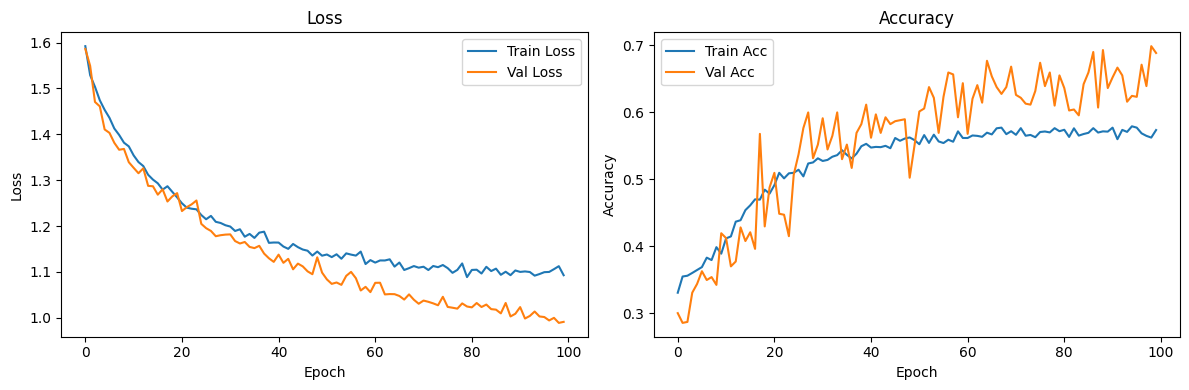

In [20]:
with open('./dataset/leap/features/features.pkl', 'rb') as f:
    features = pickle.load(f)
    
with open('./dataset/leap/features/masks.pkl', 'rb') as f:
    masks = pickle.load(f)
        
features, targets, pose_names = process_pose_labels(pose_labels_csv, video_names, features, masks)
x_train, x_test, y_train, y_test = train_test_split(features, targets, test_size=0.1)

model_cfg = dict(
    type='RecognizerGCN',
    backbone=dict(
        type='STGCN',
        graph_cfg=dict(layout='coco', mode='spatial'),
        in_channels=3,
        base_channels=64,
        num_stages=10,
        inflate_stages=[5, 8],
        down_stages=[5, 8],
    ),
    cls_head=dict(
        type='GCNHead',
        num_classes=len(pose_names),
        in_channels=256,
        dropout=0.1
    )
)

# Verify your data first
print("Data verification:")
print(f"  Number of sequences: {len(features)}")
print(f"  First feature shape: {np.array(features[0]).shape}")
print(f"  Expected: (1, T, 17, 3) or (T, 17, 3)")


# Create classifier
classifier = ClassifyingService(
    model_cfg=model_cfg,
    num_classes=len(pose_names),
    window_size=20,
    device="cuda:0",
    verbose=True  # Enable detailed logging
)

# Train
classifier.fit(x_train, y_train, x_test, y_test, epochs=100, batch_size=256, aug_range=(0.95, 1.05))

# Plot results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(classifier.history['loss'], label='Train Loss')
axes[0].plot(classifier.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(classifier.history['train_acc'], label='Train Acc')
axes[1].plot(classifier.history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy')

plt.tight_layout()
plt.show()

In [21]:
classifier.save_model('./model_weights/leap_pyskl_model.pth')

Model saved to ./model_weights/leap_pyskl_model.pth


In [23]:

import numpy as np
from collections import Counter

# 1. Load the service
classifier = ClassifyingService.load('./model_weights/leap_pyskl_model.pth')
segmentation_repository = MediapipeSegmentationRepository()
pose_labels = ["runup", "takeoff", "flight1_handplacement", "flight2", "landing"]

# 2. Get frame-by-frame labels
# feature_tensor shape: (1, Total_Frames, 17, 3)
frames, feature_tensor, mask = segmentation_repository.process_video_stgcn("./dataset/leap/videos/spreidsprong/IMG_s1.MOV")
data = classifier.predict_frame_by_frame(feature_tensor, class_names=pose_labels)
corrected_data = data.copy()

print(f"Video Length: {feature_tensor.shape[1]} frames")
print(f"Predictions Length: {len(data)} frames")

# # Step 1: Find indices of 'swing' and 'handstand'
# swing_handstand_indices = [i for i, label in enumerate(data) if label in ['swing', 'handstand']]

# # Step 2: Calculate mean index
# mean_index = np.mean(swing_handstand_indices)
# print(f"Mean index of swing/handstand: {mean_index}")

# # Step 3: Fix labels based on mean index
# # - 'landing' before mean_index -> 'starting'
# # - 'starting' after mean_index -> 'landing'
# 
# for i, label in enumerate(corrected_data):
#     if i < mean_index and label == 'landing':
#         corrected_data[i] = 'starting'
#     elif i > mean_index and label == 'starting':
#         corrected_data[i] = 'landing'

# print(f"\nAfter correction:")
# print(f"Label counts: {Counter(corrected_data)}")

# Step 4: Group labels - each label in its own contiguous section
# Calculate average position for each label to determine order
label_counts = Counter(corrected_data)
label_avg_positions = {}

for label in set(corrected_data):
    indices = [i for i, l in enumerate(corrected_data) if l == label]
    label_avg_positions[label] = np.mean(indices)

# Sort labels by their average position
sorted_labels = sorted(label_avg_positions.keys(), key=lambda x: label_avg_positions[x])
print(f"\nLabels sorted by average position: {sorted_labels}")
print(f"Average positions: {label_avg_positions}")

# Step 5: Create final grouped sequence
grouped_data = []
for label in sorted_labels:
    grouped_data.extend([label] * label_counts[label])

# Verification
print(f"\n{'='*50}")
print(f"RESULTS:")
print(f"{'='*50}")
print(f"Original length: {len(data)}")
print(f"Grouped length: {len(grouped_data)}")
print(f"\nFinal grouped sequence:")
for label in sorted_labels:
    start_idx = grouped_data.index(label)
    end_idx = start_idx + label_counts[label] - 1
    print(f"  {label}: indices {start_idx}-{end_idx} (count: {label_counts[label]})")

print(f"\nGrouped data:\n{grouped_data}")

/mnt/c/Users/Tofa/source/WorkProjects/GymnasticsAnalysis/Backend/app/services/ClassifyingService.py:461: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.loa

Initializing Model...
  - Device: cpu
  - Num Classes: 5
  - Window Size: 20
  - Backbone data_bn: BatchNorm1d(51)
  - Classification head: Linear(256, 5)
  - Total parameters: 3,074,569
Model initialized successfully!
Model loaded from ./model_weights/leap_pyskl_model.pth


W0000 00:00:1769162070.475276   15274 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769162071.562097   15275 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Video Length: 114 frames
Predictions Length: 114 frames

Labels sorted by average position: ['runup', 'takeoff', 'flight1_handplacement', 'flight2', 'landing']
Average positions: {'takeoff': 52.0, 'runup': 22.90909090909091, 'flight2': 67.5, 'flight1_handplacement': 58.5, 'landing': 88.04651162790698}

RESULTS:
Original length: 114
Grouped length: 114

Final grouped sequence:
  runup: indices 0-43 (count: 44)
  takeoff: indices 44-52 (count: 9)
  flight1_handplacement: indices 53-56 (count: 4)
  flight2: indices 57-70 (count: 14)
  landing: indices 71-113 (count: 43)

Grouped data:
['runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'runup', 'takeoff', 'ta